# Steps per launch

> Fuse several steps into one launch to cut how often the host and the
> device talk to each other — pick the number yourself, or let eagle pick
> it as the batch runs.

**Time:** ~4 min · **Runs on:** CPU (GPU: this notebook picks it up
automatically) · **You need:** {doc}`../quickstart_python`

You will build the figure below: how many launches the automatic kernel
used, grouped by how many steps each one ran.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent.parent / "_shared"))
from nb_helpers import gpu_available, xp_for


In [2]:
DEVICE = "gpu" if gpu_available() else "cpu"
xp = xp_for(DEVICE)
print("running on", DEVICE)

running on cpu


## The code: the same step, three ways

`@hawk.kernel` takes a `steps=` argument: `1` (the default you have been
using so far: one launch advances every sample by exactly one step),
a fixed `K` (one launch advances every sample by `K` steps, in registers,
no intermediate host read), or `"auto"` (eagle picks the number itself,
launch by launch, from how many samples just finished).

In [3]:
import eagle
import hawk
from hawk import Mutable, Param, Scalar, Terminated

# The step body is repeated in each kernel below, not factored into a
# helper function: a Mutable/Terminated parameter is a plain variable of
# THIS traced function, so reassigning it inside a called-out helper would
# rebind the helper's own local, not the kernel's.


@hawk.kernel(steps=1)
def oscillator_k1(omega: Scalar, t_end: Param, dt: Param, terminated: Terminated,
                   x: Mutable[Scalar], v: Mutable[Scalar], t: Mutable[Scalar]):
    x0, v0 = x, v
    x = x0 + dt * v0
    v = v0 - dt * omega * omega * x0
    t += dt
    terminated = t >= t_end


@hawk.kernel(steps=16)
def oscillator_k16(omega: Scalar, t_end: Param, dt: Param, terminated: Terminated,
                    x: Mutable[Scalar], v: Mutable[Scalar], t: Mutable[Scalar]):
    x0, v0 = x, v
    x = x0 + dt * v0
    v = v0 - dt * omega * omega * x0
    t += dt
    terminated = t >= t_end


@hawk.kernel(steps="auto")
def oscillator_auto(omega: Scalar, t_end: Param, dt: Param, terminated: Terminated,
                     x: Mutable[Scalar], v: Mutable[Scalar], t: Mutable[Scalar]):
    x0, v0 = x, v
    x = x0 + dt * v0
    v = v0 - dt * omega * omega * x0
    t += dt
    terminated = t >= t_end

In [4]:
n = 1_000_000 if DEVICE == "gpu" else 100_000
omega = xp.linspace(1.0, 3.0, n)
reports = {}
for name, kernel in [("k=1", oscillator_k1), ("k=16", oscillator_k16),
                     ("auto", oscillator_auto)]:
    reports[name] = eagle.run_until_done(
        eagle.deploy(kernel), max_steps=10_000,
        x=xp.ones(n), v=xp.zeros(n), t=xp.zeros(n),
        omega=omega, t_end=1.0, dt=1e-3)
    r = reports[name]
    print(f"{name:>5}: {r.launches:4d} launches, {r.steps:5d} steps, "
          f"exact_steps={r.exact_steps}")

  k=1: 1000 launches,  1000 steps, exact_steps=True


 k=16:   63 launches,  1008 steps, exact_steps=False


 auto:   16 launches,  1024 steps, exact_steps=False


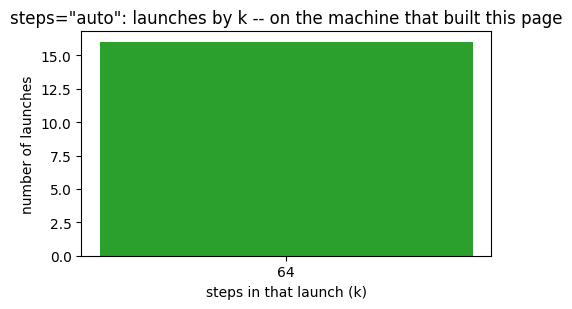

In [5]:
import matplotlib.pyplot as plt

by_k = reports["auto"].launches_by_k
fig, ax = plt.subplots(figsize=(5, 3.2))
ks = sorted(by_k)
ax.bar([str(k) for k in ks], [by_k[k] for k in ks], color="C2")
ax.set_xlabel("steps in that launch (k)")
ax.set_ylabel("number of launches")
ax.set_title("steps=\"auto\": launches by k -- on the machine that built this page")
fig.tight_layout()
plt.show()

## What just happened

- `k=1` took exactly 1000 launches for 1000 steps (`exact_steps=True`): one
  launch, one step, nothing to round.
- `k=16` took one launch per 16 steps; the last launch is cut short so no
  sample overshoots `max_steps` (`exact_steps=False` — the reported step
  count can include a partial launch).
- `"auto"` grew `k` as the batch ran: few launches total, each covering
  many steps once the policy trusted it would help. The bar chart above is
  that history.

## Small batches: the automatic policy (GPU card)

<!-- stale-prose-gate:
benchmarks/perf_card/card_quadro-p2000.json: d37837fb31567858848e5f1830f19431
-->

```{list-table} The fastest GPU arm at small N, against a hand-picked K and Warp (GPU card)
:header-rows: 1

* - Batch
  - Fastest arm
  - Closest rivals
* - N = 10^3, spread-100
  - `eagle_graph_auto` (125 us)
  - `eagle.simulate` (130 us, 1.04x); `warp_kernel` (199 us, 1.59x); `k=16` kernel, plain (345 us, 2.76x)
* - N = 10^3, spread-1000
  - `eagle_graph_auto` (879 us)
  - `eagle.simulate` (884 us, 1.01x); `warp_kernel` (1.38 ms, 1.57x); `k=16` kernel, plain (1.51 ms, 1.72x)
* - N = 10^3, uniform
  - `eagle_graph_auto` (893 us)
  - `eagle.simulate` (896 us, 1x); `eagle_graph` (1.32 ms, 1.48x); `k=16` + compaction (1.38 ms, 1.55x); `warp_kernel` (1.49 ms, 1.67x)
```

At these small batch sizes there is not enough work to amortize a launch
per step, so a fixed `K` pays for launches it does not need. The automatic
policy takes the whole run in a single launch here, and that is what
`eagle.simulate` measures. {doc}`06_compaction_and_reorder`
picks this back up for where compaction changes that story.

## On the CPU: eagle picks the tile, not you

The host loop does not guess a step count the way the GPU policy does.
Instead it asks the compiled kernel whether its fused side is a **tiled**
loop: hawk interchanges the per-sample loop so a whole tile of samples
advances together, their state held in cache, each lane masked once its own
sample is done. When it is tiled, every host launch simply asks for the
artifact's largest step count (cut to the cap on the last one) — no
sweep, no probe. The tile itself comes from the kernel's own per-sample
state size against the host's cache size, below.

In [6]:
import eagle.exec as eexec

part = eexec.Partition(0, n, n)
bytes_per_sample = 3 * 8  # oscillator's state: x, v, t -- three float64 per sample
tiles = eexec.HostTeam.tile_count(part, bytes_per_sample)
print(f"{tiles} tiles for {n:,} samples -- about {-(-n // tiles):,} samples per tile")

25 tiles for 100,000 samples -- about 4,000 samples per tile


A kernel with a bigger per-sample state (more planes, wider vectors) gets a
smaller tile; eagle works this out once from the compiled kernel, not from
`n`. That is also why {doc}`06_compaction_and_reorder`'s active-set map has
little left to do on the CPU: a tile already skips a finished lane instead
of computing it, for the samples still in cache together.

## Try this

Change `dt` to `1e-4` (ten times more steps) and compare `auto`'s launch
count against `k=16`'s — `auto` should still win on launch count.

## Next

- {doc}`06_compaction_and_reorder` — the other side of a thinning batch:
  skip finished samples' *lanes*, not just their steps.
- deeper: {doc}`../../performance` ("The ways of running it", "K fused
  steps per launch").